# Task 4 — Deep Learning Fundamentals
**10 Points** | Multi-Layer Perceptron · Optimizers · Regularization

---

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('../results', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
torch.manual_seed(42)

Using device: cpu


In [13]:
# Load and preprocess Dataset A (Breast Cancer)
data = load_breast_cancer()
X = data.data.astype(np.float32)
y = data.target.astype(np.int64)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

def to_loader(X, y, batch_size=32, shuffle=True):
    """Convert numpy arrays to PyTorch DataLoader."""
    ds = TensorDataset(
        torch.FloatTensor(X).to(device),
        torch.LongTensor(y).to(device)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train)
val_loader = to_loader(X_val, y_val, shuffle=False)
test_loader = to_loader(X_test, y_test, shuffle=False)

n_features = X.shape[1]
n_classes = len(np.unique(y))
print(f'Features: {n_features}, Classes: {n_classes}')
print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Features: 30, Classes: 2
Train: 398, Val: 85, Test: 86


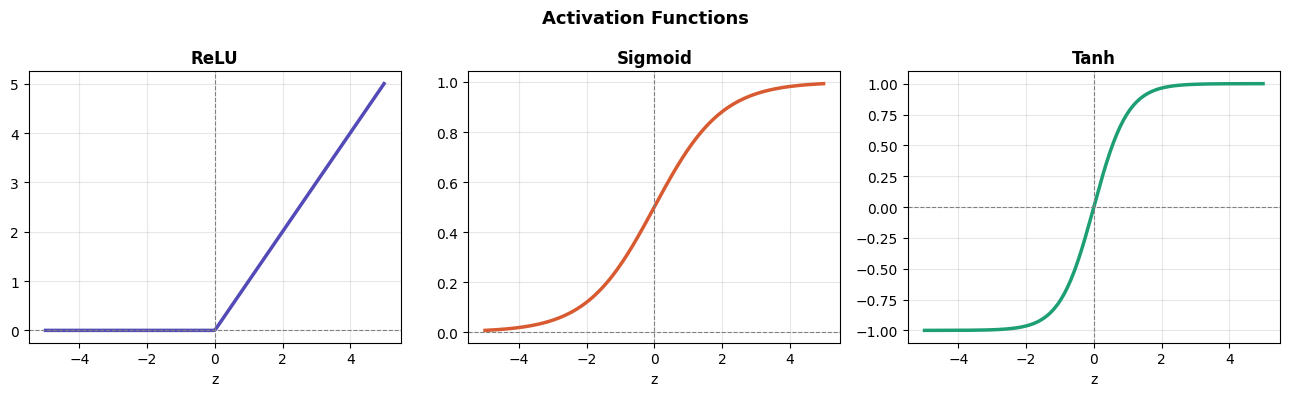

Softmax input (logits): [ 2.   1.   0.5 -1. ]
Softmax output (probs): [0.6095 0.2242 0.136  0.0303]
Sum: 1.0

── Loss Functions ──
Cross-Entropy (good pred): 0.0868
Cross-Entropy (bad pred):  2.4868
MSE Loss: 0.0200

── Backpropagation Demo ──
Step 1: w=2.0000, loss=25.0000, grad=30.0000
Step 2: w=-1.0000, loss=16.0000, grad=-24.0000
Step 3: w=1.4000, loss=10.2400, grad=19.2000
Step 4: w=-0.5200, loss=6.5536, grad=-15.3600
Step 5: w=1.0160, loss=4.1943, grad=12.2880


In [14]:
# ── Core Concepts Demo ────────────────────────────────────────────
# Демонстрация: активации, loss функции, backprop — требование задания

# 1. Activation Functions
z = torch.linspace(-5, 5, 200)
activations = {
    'ReLU':    nn.ReLU()(z),
    'Sigmoid': nn.Sigmoid()(z),
    'Tanh':    nn.Tanh()(z),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#534AB7', '#D85A30', '#1D9E75']
for ax, (name, vals), color in zip(axes, activations.items(), colors):
    ax.plot(z.numpy(), vals.numpy(), lw=2.5, color=color)
    ax.axhline(0, color='gray', lw=0.8, linestyle='--')
    ax.axvline(0, color='gray', lw=0.8, linestyle='--')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('z'); ax.grid(True, alpha=0.3)
plt.suptitle('Activation Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/task4_activations.png', dpi=150, bbox_inches='tight')
plt.show()

# Softmax — отдельно (на векторе логитов)
logits = torch.tensor([2.0, 1.0, 0.5, -1.0])
softmax_out = nn.Softmax(dim=0)(logits)
print('Softmax input (logits):', logits.numpy())
print('Softmax output (probs):', softmax_out.numpy().round(4))
print('Sum:', softmax_out.sum().item())

# 2. Loss Functions
print('\n── Loss Functions ──')
y_true_demo = torch.tensor([1])          # истинный класс
logits_good  = torch.tensor([[0.1, 2.5]]) # уверенно правильный
logits_bad   = torch.tensor([[2.5, 0.1]]) # уверенно неправильный

ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

print(f'Cross-Entropy (good pred): {ce_loss(logits_good, y_true_demo):.4f}')
print(f'Cross-Entropy (bad pred):  {ce_loss(logits_bad,  y_true_demo):.4f}')

# MSE — используется для регрессии
y_reg_true = torch.tensor([1.0, 0.0, 1.0])
y_reg_pred = torch.tensor([0.9, 0.1, 0.8])
print(f'MSE Loss: {mse_loss(y_reg_pred, y_reg_true):.4f}')

# 3. Backpropagation & Gradient Descent — простой пример
print('\n── Backpropagation Demo ──')
w = torch.tensor(2.0, requires_grad=True)  # параметр
x = torch.tensor(3.0)                       # вход
y_target = torch.tensor(1.0)                # цель

lr = 0.1
for step in range(5):
    y_pred = w * x                          # forward pass
    loss = (y_pred - y_target) ** 2         # MSE loss
    loss.backward()                         # backprop
    print(f'Step {step+1}: w={w.item():.4f}, loss={loss.item():.4f}, grad={w.grad.item():.4f}')
    with torch.no_grad():
        w -= lr * w.grad                    # gradient descent
    w.grad.zero_()                          # обнулить градиент

## 1. MLP Implementation

In [15]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron with:
    - 3 hidden layers
    - Configurable activation function
    - BatchNorm + Dropout regularization
    """
    def __init__(self, in_features, n_classes, hidden_dims=[256, 128, 64],
                 activation='relu', dropout_rate=0.3):
        super(MLP, self).__init__()

        act_map = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'leaky_relu': nn.LeakyReLU(0.1)
        }
        act_fn = act_map.get(activation, nn.ReLU())

        layers = []
        prev_dim = in_features
        for i, h_dim in enumerate(hidden_dims):
            layers += [
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                act_map.get(activation, nn.ReLU()),  # fresh instance per layer
                nn.Dropout(p=dropout_rate)
            ]
            prev_dim = h_dim

        layers.append(nn.Linear(prev_dim, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_epoch(model, loader, optimizer, criterion):
    """Run one training epoch, return mean loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    """Evaluate model on a dataloader, return mean loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, n_epochs=60, scheduler=None):
    """Full training loop. Returns history dict."""
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if scheduler:
            scheduler.step(vl_loss)

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}/{n_epochs} | '
                  f'Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | '
                  f'Val Loss: {vl_loss:.4f}, Acc: {vl_acc:.4f}')

    return history


def plot_history(history, title='Training History', save_path=None):
    """Plot loss and accuracy curves."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(epochs, history['train_loss'], color='#534AB7', label='Train')
    axes[0].plot(epochs, history['val_loss'], color='#D85A30', label='Validation')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], color='#534AB7', label='Train')
    axes[1].plot(epochs, history['val_acc'], color='#D85A30', label='Validation')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print('Model classes defined.')

Model classes defined.


=== MLP with ReLU + BatchNorm + Dropout ===


Epoch  10/60 | Train Loss: 0.0834, Acc: 0.9774 | Val Loss: 0.0434, Acc: 0.9882
Epoch  20/60 | Train Loss: 0.1047, Acc: 0.9673 | Val Loss: 0.0426, Acc: 0.9765
Epoch  30/60 | Train Loss: 0.0718, Acc: 0.9724 | Val Loss: 0.0431, Acc: 0.9765
Epoch  40/60 | Train Loss: 0.0477, Acc: 0.9824 | Val Loss: 0.0237, Acc: 1.0000
Epoch  50/60 | Train Loss: 0.0825, Acc: 0.9774 | Val Loss: 0.0263, Acc: 1.0000
Epoch  60/60 | Train Loss: 0.0278, Acc: 0.9950 | Val Loss: 0.0249, Acc: 0.9882


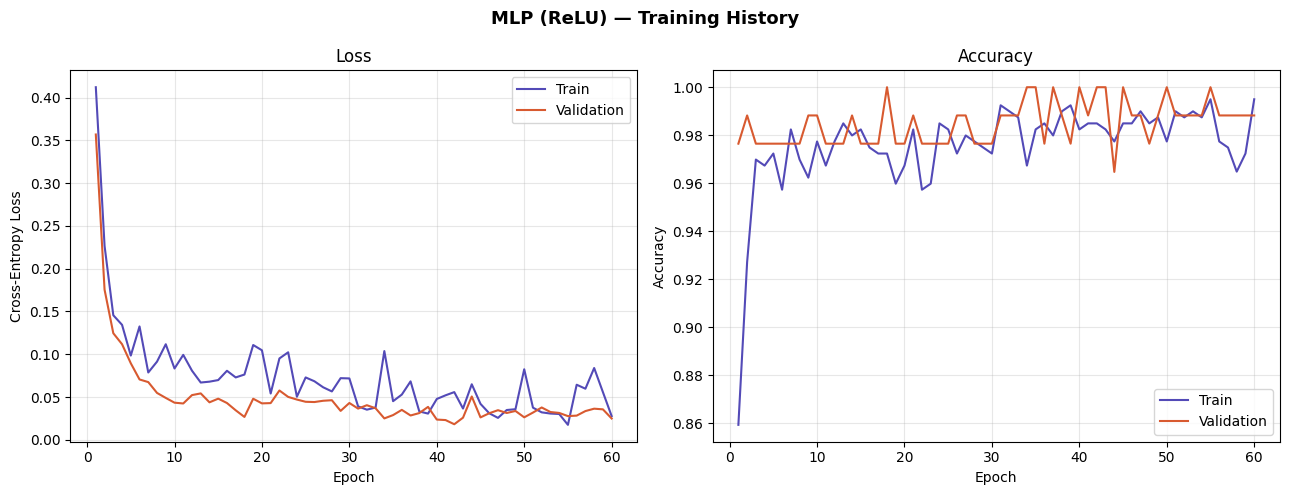


=== MLP with Tanh activation ===
Epoch  10/60 | Train Loss: 0.1510, Acc: 0.9447 | Val Loss: 0.0437, Acc: 0.9882
Epoch  20/60 | Train Loss: 0.0705, Acc: 0.9749 | Val Loss: 0.0316, Acc: 0.9882
Epoch  30/60 | Train Loss: 0.0923, Acc: 0.9724 | Val Loss: 0.0311, Acc: 0.9882
Epoch  40/60 | Train Loss: 0.0731, Acc: 0.9724 | Val Loss: 0.0304, Acc: 1.0000
Epoch  50/60 | Train Loss: 0.0791, Acc: 0.9698 | Val Loss: 0.0253, Acc: 0.9882
Epoch  60/60 | Train Loss: 0.0842, Acc: 0.9598 | Val Loss: 0.0426, Acc: 0.9882


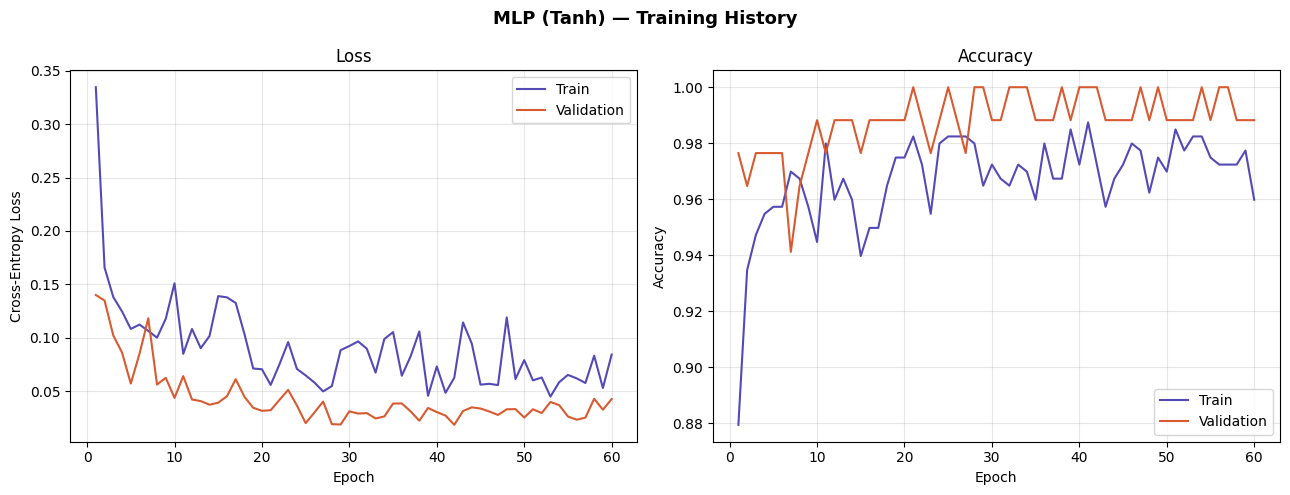

In [16]:
# Train MLP with ReLU activation
print('=== MLP with ReLU + BatchNorm + Dropout ===')
model_relu = MLP(n_features, n_classes, activation='relu', dropout_rate=0.3).to(device)
optimizer_relu = optim.Adam(model_relu.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_relu = optim.lr_scheduler.ReduceLROnPlateau(optimizer_relu, patience=10, factor=0.5)

history_relu = train_model(model_relu, train_loader, val_loader,
                           optimizer_relu, n_epochs=60, scheduler=scheduler_relu)
plot_history(history_relu, 'MLP (ReLU) — Training History',
             '../results/task4_mlp_relu_history.png')

# Train MLP with Tanh activation
print('\n=== MLP with Tanh activation ===')
model_tanh = MLP(n_features, n_classes, activation='tanh', dropout_rate=0.3).to(device)
optimizer_tanh = optim.Adam(model_tanh.parameters(), lr=1e-3, weight_decay=1e-4)

history_tanh = train_model(model_tanh, train_loader, val_loader,
                            optimizer_tanh, n_epochs=60)
plot_history(history_tanh, 'MLP (Tanh) — Training History',
             '../results/task4_mlp_tanh_history.png')

## 2. Optimizer Study — SGD vs Adam vs RMSProp


Training with SGD (lr=0.01)...
Epoch  10/60 | Train Loss: 0.0899, Acc: 0.9774 | Val Loss: 0.0417, Acc: 0.9882
Epoch  20/60 | Train Loss: 0.1094, Acc: 0.9623 | Val Loss: 0.0457, Acc: 0.9765
Epoch  30/60 | Train Loss: 0.0793, Acc: 0.9673 | Val Loss: 0.0406, Acc: 0.9765
Epoch  40/60 | Train Loss: 0.0466, Acc: 0.9824 | Val Loss: 0.0287, Acc: 0.9882
Epoch  50/60 | Train Loss: 0.0814, Acc: 0.9749 | Val Loss: 0.0333, Acc: 0.9882
Epoch  60/60 | Train Loss: 0.0398, Acc: 0.9849 | Val Loss: 0.0298, Acc: 1.0000

Training with RMSProp...
Epoch  10/60 | Train Loss: 0.0718, Acc: 0.9799 | Val Loss: 0.0410, Acc: 0.9882
Epoch  20/60 | Train Loss: 0.0919, Acc: 0.9673 | Val Loss: 0.0359, Acc: 1.0000
Epoch  30/60 | Train Loss: 0.0660, Acc: 0.9724 | Val Loss: 0.0405, Acc: 0.9882
Epoch  40/60 | Train Loss: 0.0505, Acc: 0.9824 | Val Loss: 0.0224, Acc: 1.0000
Epoch  50/60 | Train Loss: 0.1039, Acc: 0.9749 | Val Loss: 0.0249, Acc: 0.9882
Epoch  60/60 | Train Loss: 0.0381, Acc: 0.9849 | Val Loss: 0.0364, Acc: 0

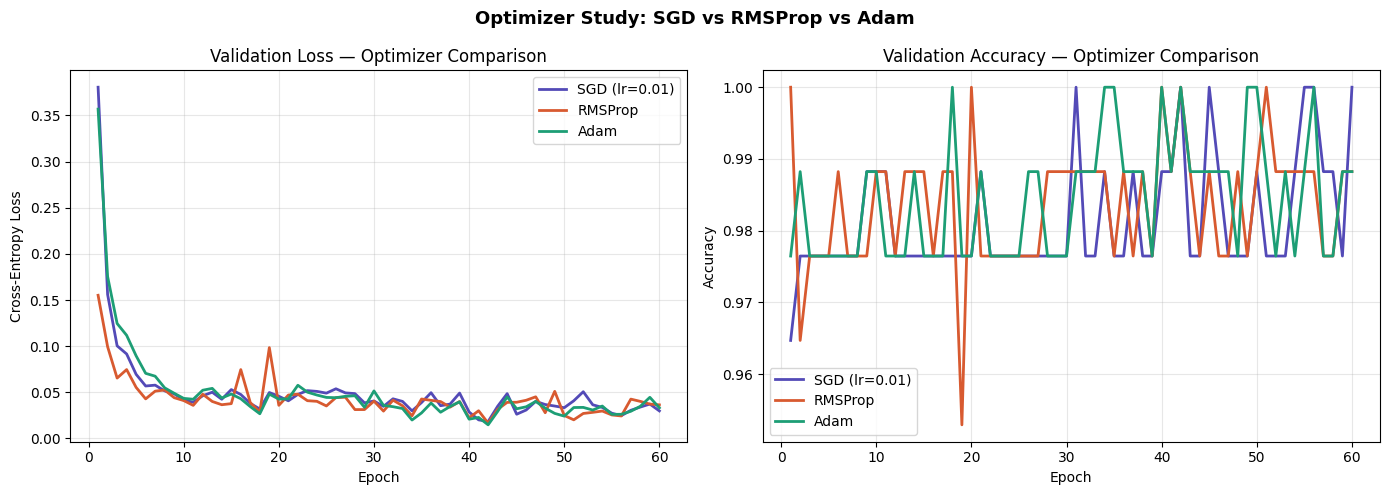


--- Convergence Analysis ---
SGD (lr=0.01)        | Final val acc: 1.0000 | Epochs to 90%: 1
RMSProp              | Final val acc: 0.9882 | Epochs to 90%: 1
Adam                 | Final val acc: 0.9882 | Epochs to 90%: 1


In [17]:
optimizer_configs = {
    'SGD (lr=0.01)':   lambda p: optim.SGD(p, lr=0.01, momentum=0.9, weight_decay=1e-4),
    'RMSProp':         lambda p: optim.RMSprop(p, lr=1e-3, weight_decay=1e-4),
    'Adam':            lambda p: optim.Adam(p, lr=1e-3, weight_decay=1e-4),
}

opt_histories = {}

for opt_name, opt_fn in optimizer_configs.items():
    print(f'\nTraining with {opt_name}...')
    model = MLP(n_features, n_classes, activation='relu', dropout_rate=0.3).to(device)
    torch.manual_seed(42)  # Same init for fair comparison
    model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)
    optimizer = opt_fn(model.parameters())
    history = train_model(model, train_loader, val_loader, optimizer, n_epochs=60)
    opt_histories[opt_name] = history

# Plot all optimizers together
colors = {'SGD (lr=0.01)': '#534AB7', 'RMSProp': '#D85A30', 'Adam': '#1D9E75'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for opt_name, history in opt_histories.items():
    epochs = range(1, len(history['val_loss']) + 1)
    axes[0].plot(epochs, history['val_loss'], label=opt_name, color=colors[opt_name], lw=2)
    axes[1].plot(epochs, history['val_acc'], label=opt_name, color=colors[opt_name], lw=2)

axes[0].set_title('Validation Loss — Optimizer Comparison')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy — Optimizer Comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimizer Study: SGD vs RMSProp vs Adam', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/task4_optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Convergence speed (epochs to reach 90% val accuracy)
print('\n--- Convergence Analysis ---')
for opt_name, history in opt_histories.items():
    accs = history['val_acc']
    thresh = 0.90
    epoch_reached = next((i+1 for i, a in enumerate(accs) if a >= thresh), None)
    final_acc = accs[-1]
    print(f'{opt_name:20s} | Final val acc: {final_acc:.4f} | Epochs to {thresh:.0%}: {epoch_reached}')

## 3. Conceptual Questions

### a) Vanishing Gradient Problem

The **vanishing gradient problem** occurs during backpropagation in deep networks. Gradients are computed via the chain rule:

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial a_L} \cdot \prod_{l=2}^{L} \frac{\partial a_l}{\partial a_{l-1}}$$

When activation functions like sigmoid or tanh are used, their derivatives saturate at 0 for large input values ($\sigma'(x) \leq 0.25$). Multiplying many such small values across layers causes gradients to shrink exponentially, making early layers train extremely slowly or not at all.

**Modern solutions:**
- **ReLU and variants (Leaky ReLU, ELU):** $f'(x) = 1$ for $x > 0$ — gradient flows through without attenuation
- **Residual connections (ResNet):** $y = F(x) + x$ — gradients flow directly through skip connections
- **Batch Normalization:** normalizes activations, keeping them in the non-saturated range
- **Careful weight initialization (He, Xavier):** ensures initial variance is appropriate for the activation function

---

### b) Why Batch Normalization Accelerates Training

**Internal Covariate Shift** occurs when the distribution of activations changes across mini-batches as parameters update. This forces subsequent layers to continuously adapt, slowing training.

Batch Normalization normalizes activations within each mini-batch:

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

where:
- $\mu_B = \frac{1}{m}\sum_{i=1}^m x_i$ (mini-batch mean)
- $\sigma_B^2 = \frac{1}{m}\sum_{i=1}^m (x_i - \mu_B)^2$ (mini-batch variance)

Then rescales with learnable parameters:
$$y_i = \gamma \hat{x}_i + \beta$$

**Benefits:** Allows higher learning rates (smoother loss surface), reduces sensitivity to initialization, acts as a regularizer (adds noise via batch statistics), and keeps activations in the linear regime of activation functions.

---

### c) Role of Learning Rate

The learning rate $\eta$ controls the step size of gradient descent parameter updates:

$$\theta_{t+1} = \theta_t - \eta \nabla_\theta L(\theta_t)$$

**Too high ($\eta \gg$):** Overshoots minima — loss oscillates or diverges. The optimizer bounces around the loss landscape and may never converge.

**Too low ($\eta \ll$):** Training is very slow. The model may get stuck in local minima or saddle points, and convergence requires many epochs.

**Optimal range:** Typically $10^{-4}$ to $10^{-2}$ depending on architecture and optimizer. **Learning rate schedules** (step decay, cosine annealing, ReduceLROnPlateau) are used to start with a larger rate for fast initial progress, then reduce it for fine-grained convergence near the minimum.

In [18]:
# Final test evaluation
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for X_batch, y_batch in loader:
        preds = model(X_batch).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
    return np.array(all_targets), np.array(all_preds)

y_true, y_pred = get_predictions(model_relu, test_loader)
print('=== MLP (ReLU) — Test Set Report ===')
print(classification_report(y_true, y_pred,
      target_names=load_breast_cancer().target_names))
print(f'Test Accuracy: {accuracy_score(y_true, y_pred):.4f}')

# Save model
torch.save(model_relu.state_dict(), '../results/task4_mlp_relu.pth')
print('Model saved to results/task4_mlp_relu.pth')

=== MLP (ReLU) — Test Set Report ===
              precision    recall  f1-score   support

   malignant       1.00      0.91      0.95        32
      benign       0.95      1.00      0.97        54

    accuracy                           0.97        86
   macro avg       0.97      0.95      0.96        86
weighted avg       0.97      0.97      0.96        86

Test Accuracy: 0.9651
Model saved to results/task4_mlp_relu.pth
